# **DATA SET INFORMATION:**

This dataset is composed of a range of biomedical voice measurements from 42
people with early-stage Parkinson's disease recruited to a six-month trial of
a telemonitoring device for remote symptom progression monitoring. The
recordings were automatically captured in the patient's homes.

The main aim of the data is to predict the
motor and total UPDRS scores ('motor_UPDRS' and 'total_UPDRS') from the 16
voice measures. The progression of disease based on biomedical voice
measurements.

Unified Parkinson's disease rating scale (UPDRS)

## Summary of EDA Methodology
The steps for exploratory data analysis:

1.  **Data Loading and Initial Inspection:**
    *   Loaded the dataset using pandas to inspect the first few rows, data types, and non-null values.
    *   Checked the shape of the dataset (number of rows and columns).

2.  **Outlier Detection and Handling:**
    *   Identified outliers using the Interquartile Range (IQR) method.
    *   Visualized outliers using boxplots for continuous features.
    *   Handled outliers by capping them at the calculated upper and lower bounds.

3.  **Feature Correlation Analysis:**
    *   Computed the correlation matrix for all numerical features to understand linear relationships.
    *   Visualized the correlation matrix using a heatmap.
    *   Identified the top features most correlated with the target variable (`total_UPDRS`).

4.  **Visualizing Feature Relationships:**
    *   Generated a pairplot (on a sampled subset for performance) to visualize pairwise relationships between features and the distribution of individual features.
    *   Created a pairwise scatter matrix for the top correlated features and the target variable.
    *   Visualized the distribution of the target variable using a histogram and KDE plot.
    *   Created scatter plots to visualize the relationship between `motor_UPDRS` and `total_UPDRS`, and between RPDE, PPE, and the UPDRS scores.

5.  **Analysis of Specific Feature Relationships:**
    *   Examined the correlations of Jitter and Shimmer feature groups with UPDRS scores.
    *   Analyzed the scatter plots for RPDE and PPE vs. UPDRS scores to understand their non-linear relationships.

This EDA process has provided insights into the data's structure, potential issues (like outliers), relationships between features, and the distribution of the target variable, which will be valuable for subsequent modeling steps.

## Data Preparation and Loading

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install statsmodels
from sklearn.preprocessing import StandardScaler

### Initial Data Exploration

In [7]:
# Loading the dataset using Pandas
df = pd.read_csv('/content/parkinsons_updrs.data')
df.head(15)

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361
5,1,72,0,40.6520,29.435,36.870,0.00353,0.000023,0.00119,0.00159,...,0.214,0.01006,0.01337,0.02263,0.03019,0.009438,22.946,0.53949,0.57243,0.19500
6,1,72,0,47.6490,29.682,37.363,0.00422,0.000024,0.00212,0.00221,...,0.445,0.02376,0.02621,0.03488,0.07128,0.013260,22.506,0.49250,0.54779,0.17563
7,1,72,0,54.6400,29.928,37.857,0.00476,0.000025,0.00226,0.00259,...,0.212,0.00979,0.01462,0.01911,0.02937,0.027969,22.929,0.47712,0.54234,0.23844
8,1,72,0,61.6690,30.177,38.353,0.00432,0.000029,0.00156,0.00207,...,0.371,0.01774,0.02134,0.03451,0.05323,0.013381,22.078,0.51563,0.61864,0.20037
9,1,72,0,68.6880,30.424,38.849,0.00496,0.000027,0.00258,0.00253,...,0.310,0.02030,0.01970,0.02569,0.06089,0.018021,22.606,0.50032,0.58673,0.20117


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5875 entries, 0 to 5874
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   subject#       5875 non-null   int64  
 1   age            5875 non-null   int64  
 2   sex            5875 non-null   int64  
 3   test_time      5875 non-null   float64
 4   motor_UPDRS    5875 non-null   float64
 5   total_UPDRS    5875 non-null   float64
 6   Jitter(%)      5875 non-null   float64
 7   Jitter(Abs)    5875 non-null   float64
 8   Jitter:RAP     5875 non-null   float64
 9   Jitter:PPQ5    5875 non-null   float64
 10  Jitter:DDP     5875 non-null   float64
 11  Shimmer        5875 non-null   float64
 12  Shimmer(dB)    5875 non-null   float64
 13  Shimmer:APQ3   5875 non-null   float64
 14  Shimmer:APQ5   5875 non-null   float64
 15  Shimmer:APQ11  5875 non-null   float64
 16  Shimmer:DDA    5875 non-null   float64
 17  NHR            5875 non-null   float64
 18  HNR     

The dataset has 2 data types integers and float, with non-null values

In [9]:
df.isnull().sum()

,0
subject#,0
age,0
sex,0
test_time,0
motor_UPDRS,0
total_UPDRS,0
Jitter(%),0
Jitter(Abs),0
Jitter:RAP,0
Jitter:PPQ5,0


In [10]:
df.shape

(5875, 22)

In [11]:
# Remove the 'gender' column and then call .describe()
df_without_sex = df.drop(columns=['sex'])
display(df_without_sex.describe())

,subject#,age,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,Jitter:DDP,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
count,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,...,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000
mean,21.494128,64.804936,92.863722,21.296229,29.018942,0.006154,0.000044,0.002987,0.003277,0.008962,...,0.310960,0.017156,0.020144,0.027481,0.051467,0.032120,21.679495,0.541473,0.653240,0.219589
std,12.372279,8.821524,53.445602,8.129282,10.700283,0.005624,0.000036,0.003124,0.003732,0.009371,...,0.230254,0.013237,0.016664,0.019986,0.039711,0.059692,4.291096,0.100986,0.070902,0.091498
min,1.000000,36.000000,-4.262500,5.037700,7.000000,0.000830,0.000002,0.000330,0.000430,0.000980,...,0.026000,0.001610,0.001940,0.002490,0.004840,0.000286,1.659000,0.151020,0.514040,0.021983
25%,10.000000,58.000000,46.847500,15.000000,21.371000,0.003580,0.000022,0.001580,0.001820,0.004730,...,0.175000,0.009280,0.010790,0.015665,0.027830,0.010955,19.406000,0.469785,0.596180,0.156340
50%,22.000000,65.000000,91.523000,20.871000,27.576000,0.004900,0.000035,0.002250,0.002490,0.006750,...,0.253000,0.013700,0.015940,0.022710,0.041110,0.018448,21.920000,0.542250,0.643600,0.205500
75%,33.000000,72.000000,138.445000,27.596500,36.399000,0.006800,0.000053,0.003290,0.003460,0.009870,...,0.365000,0.020575,0.023755,0.032715,0.061735,0.031463,24.444000,0.614045,0.711335,0.264490
max,42.000000,85.000000,215.490000,39.511000,54.992000,0.099990,0.000446,0.057540,0.069560,0.172630,...,2.107000,0.162670,0.167020,0.275460,0.488020,0.748260,37.875000,0.966080,0.865600,0.731730


The minimum age for the participate was 36 years and the maximum was 85 years. The minimum NHR is 0 and the max is 0.75. The HNR min is 1.66 and max 37.88

### Outlier Detection and Handling

In [12]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()
print("\n🚨 Outliers per Column:")
print(outliers)


🚨 Outliers per Column:
subject#           0
age              101
sex                0
test_time          0
motor_UPDRS        0
total_UPDRS        0
Jitter(%)        398
Jitter(Abs)      366
Jitter:RAP       414
Jitter:PPQ5      425
Jitter:DDP       413
Shimmer          333
Shimmer(dB)      332
Shimmer:APQ3     332
Shimmer:APQ5     314
Shimmer:APQ11    314
Shimmer:DDA      331
NHR              436
HNR              171
RPDE              26
DFA                0
PPE              206
dtype: int64


The following columns do not have outliers:
sex, subject, test_time, motor_UPDRS,total_UPDRS, DFA

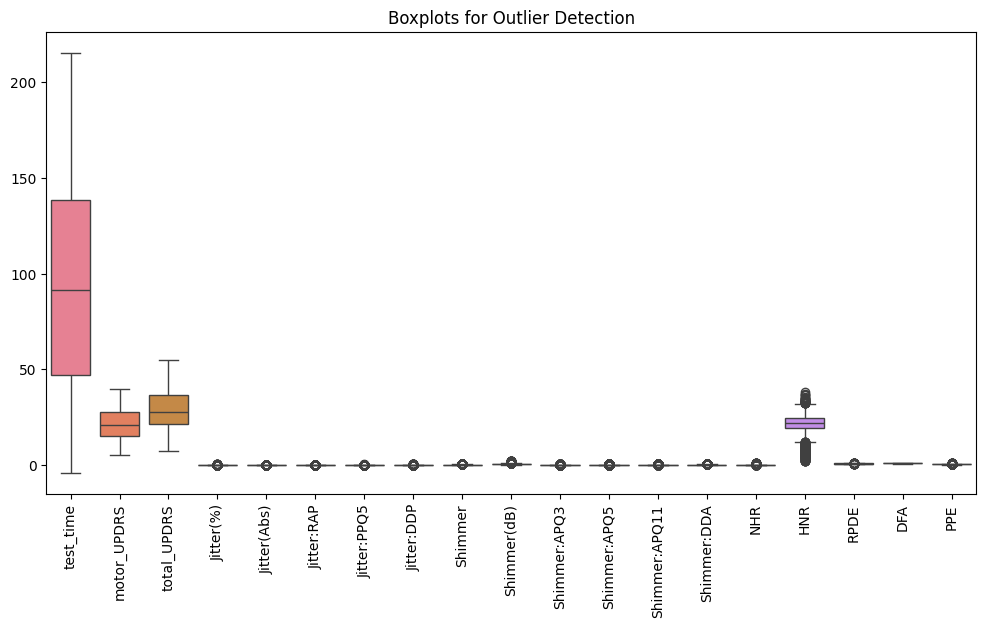

In [13]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include='float64'))
plt.title("Boxplots for Outlier Detection")
plt.xticks(rotation=90)
plt.show()

A boxplot for all continuous variables highlights the presence of outliers in Jitter, Shimmer, NHR, RPDE, and PPE.

These outliers represent recordings where voice irregularities (like tremor or breathiness) were extreme, possibly due to fluctuations in  ambient noise.


In [14]:
# Identify columns with outliers (excluding 'subject#', 'sex', 'test_time', motor_UPDRS, total_UPDRS, DFA which had none)
outlier_cols = ['age', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP',
                'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11',
                'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'PPE']

# Apply capping
df2 = df.copy() # Create a copy to avoid modifying the original DataFrame

for col in outlier_cols:
    lower_bound = Q1[col] - 1.5 * IQR[col]
    upper_bound = Q3[col] + 1.5 * IQR[col]
    df2[col] = df2[col].clip(lower=lower_bound, upper=upper_bound)

print("Outliers handled by capping. Displaying the first 5 rows of the capped DataFrame:")
display(df2.head())

Outliers handled by capping. Displaying the first 5 rows of the capped DataFrame:


,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


###  Correlation Analysis

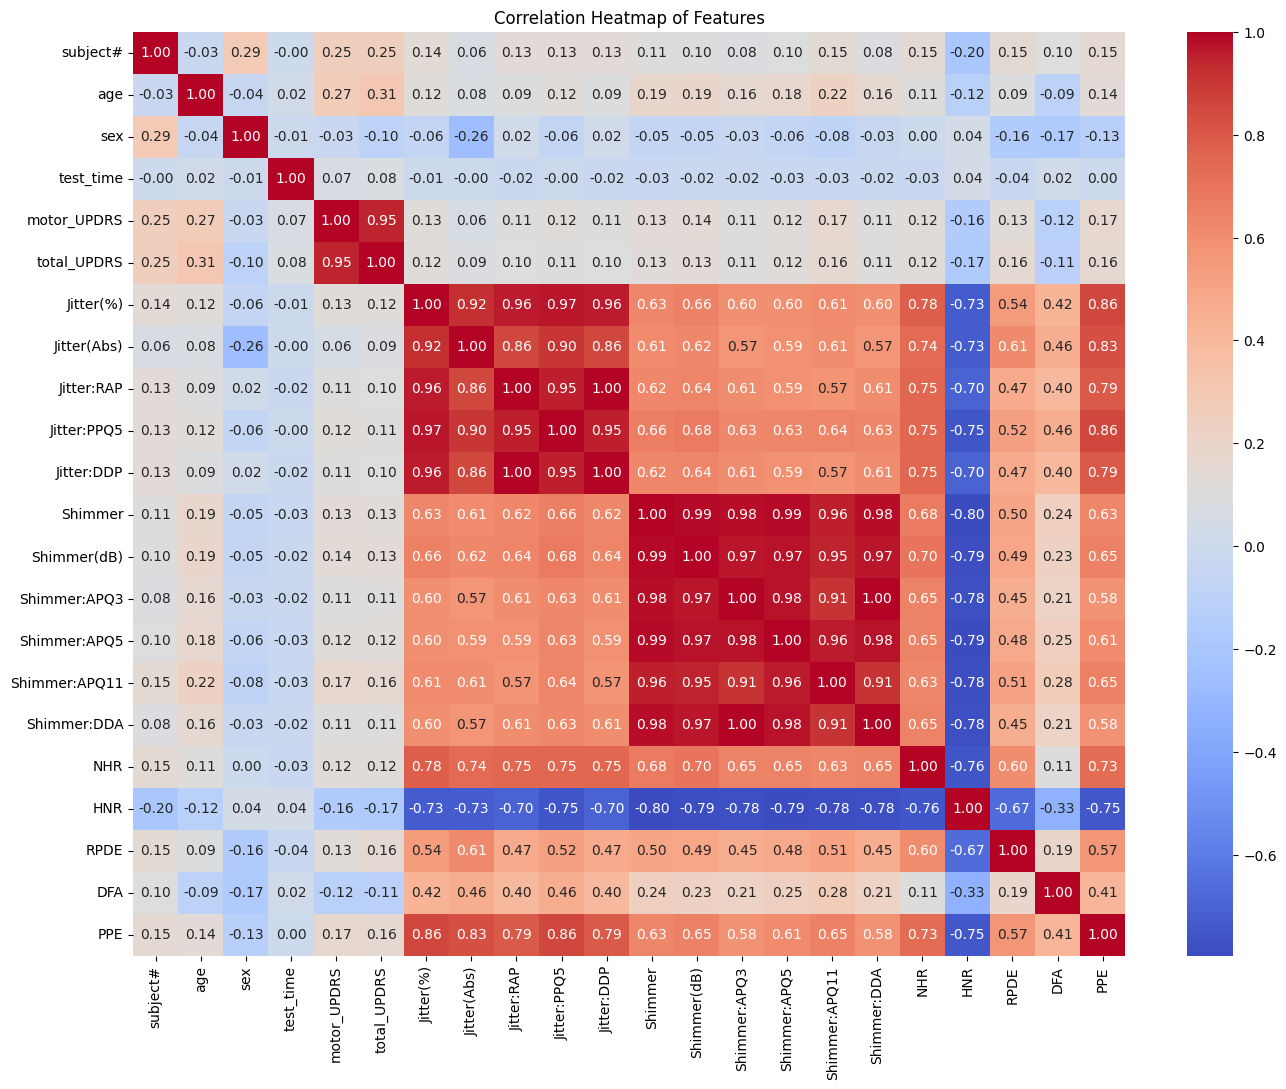

In [47]:
corr = df2.corr()
plt.figure(figsize=(16, 12)) # Increased figure size
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f") # Set annot=True and format numbers
plt.title("Correlation Heatmap of Features")
plt.show()

In [45]:
display(corr)

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
subject#,1.000000,-0.029393,0.286851,-0.000882,0.252919,0.253643,0.140908,0.063137,0.133202,0.131782,...,0.103288,0.083029,0.095763,0.147644,0.083050,0.146470,-0.198311,0.146824,0.097464,0.152449
age,-0.029393,1.000000,-0.038991,0.019696,0.272654,0.309320,0.118590,0.080679,0.093864,0.119533,...,0.192916,0.159060,0.175999,0.222533,0.159023,0.111530,-0.121828,0.091755,-0.094742,0.136812
sex,0.286851,-0.038991,1.000000,-0.009805,-0.031205,-0.096559,-0.057726,-0.261268,0.021387,-0.062131,...,-0.054350,-0.033682,-0.060200,-0.084370,-0.033637,0.003659,0.036568,-0.161650,-0.165113,-0.125206
test_time,-0.000882,0.019696,-0.009805,1.000000,0.067918,0.075263,-0.006863,-0.004574,-0.020119,-0.004638,...,-0.021241,-0.020369,-0.027099,-0.027452,-0.020371,-0.027806,0.036252,-0.037418,0.019261,0.000786
motor_UPDRS,0.252919,0.272654,-0.031205,0.067918,1.000000,0.947231,0.125301,0.056320,0.106399,0.122804,...,0.137247,0.106147,0.118396,0.166210,0.106137,0.124950,-0.163213,0.128087,-0.116242,0.165534
total_UPDRS,0.253643,0.309320,-0.096559,0.075263,0.947231,1.000000,0.118287,0.085890,0.101202,0.114896,...,0.133894,0.109623,0.120186,0.158613,0.109609,0.120699,-0.171240,0.156328,-0.113475,0.161505
Jitter(%),0.140908,0.118590,-0.057726,-0.006863,0.125301,0.118287,1.000000,0.919225,0.963928,0.967422,...,0.655230,0.596742,0.599133,0.613269,0.596750,0.781670,-0.728997,0.537678,0.424006,0.859078
Jitter(Abs),0.063137,0.080679,-0.261268,-0.004574,0.056320,0.085890,0.919225,1.000000,0.857901,0.902493,...,0.622983,0.571020,0.588097,0.606471,0.571030,0.739880,-0.730516,0.614976,0.458057,0.830572
Jitter:RAP,0.133202,0.093864,0.021387,-0.020119,0.106399,0.101202,0.963928,0.857901,1.000000,0.952514,...,0.638471,0.606519,0.588033,0.574382,0.606527,0.752975,-0.701354,0.469845,0.395999,0.790647
Jitter:PPQ5,0.131782,0.119533,-0.062131,-0.004638,0.122804,0.114896,0.967422,0.902493,0.952514,1.000000,...,0.677126,0.627896,0.634759,0.640647,0.627898,0.753753,-0.754934,0.519226,0.456070,0.858182


Displays correlations between all numerical features, including UPDRS scores.

High correlations exist between motor_UPDRS and total_UPDRS, while several acoustic features are intercorrelated (e.g., Jitter and Shimmer variants).


In [16]:
# Identify target variable correlations (assuming 'total_UPDRS')
if 'total_UPDRS' in df2.columns:
    target = 'total_UPDRS'
elif 'total_updrs' in df2.columns:
    target = 'total_updrs'
else:
    target = df.columns[-1] # fallback


correlations = df2.corr()[target].sort_values(ascending=False)
print("\n🔥 Top 10 Most Correlated Features with Target:")
print(correlations.head(10))


🔥 Top 10 Most Correlated Features with Target:
total_UPDRS      1.000000
motor_UPDRS      0.947231
age              0.309320
subject#         0.253643
PPE              0.161505
Shimmer:APQ11    0.158613
RPDE             0.156328
Shimmer(dB)      0.133894
Shimmer          0.128329
NHR              0.120699
Name: total_UPDRS, dtype: float64


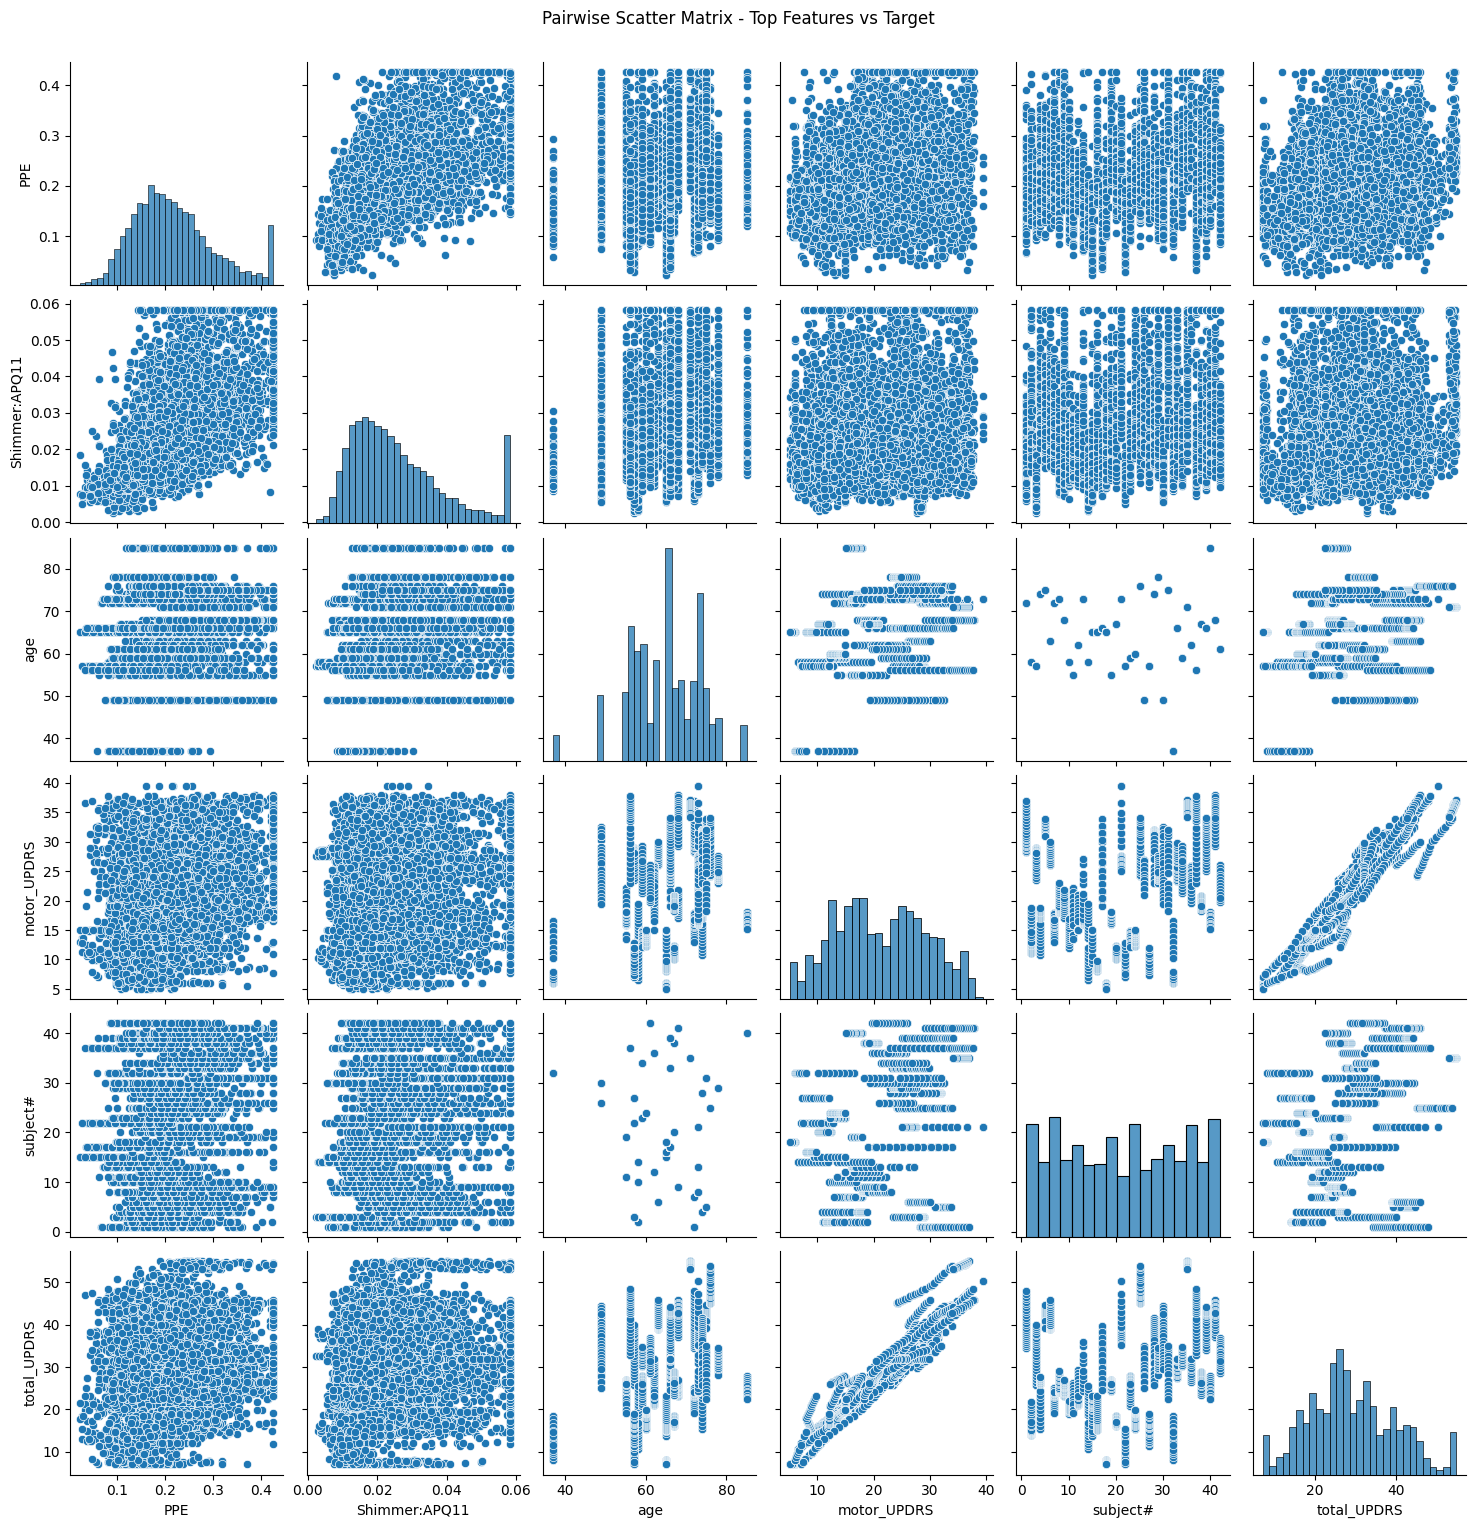

In [32]:
# 5. Pairwise correlation scatter matrix for top 5 correlated features
sns.pairplot(df2[top_features.union([target])])
plt.suptitle("Pairwise Scatter Matrix - Top Features vs Target", y=1.02)
plt.show()

### Visualizing Relationships

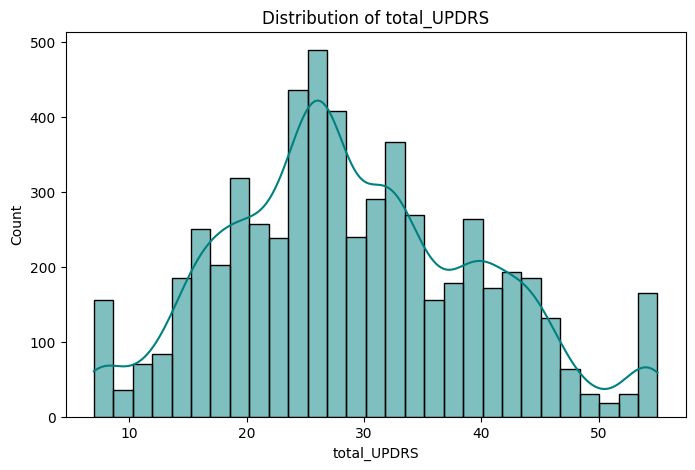

In [35]:
# Histogram of target variable
plt.figure(figsize=(8,5))
sns.histplot(df2[target], kde=True, color='teal')
plt.title(f"Distribution of {target}")
plt.show()


The histogram visualizes the frequency distribution of the total_UPDRS scores across all 5,875 voice recordings.The curve is right-skewed, meaning most patients have lower UPDRS scores (milder symptoms), with fewer recordings at higher severity levels.


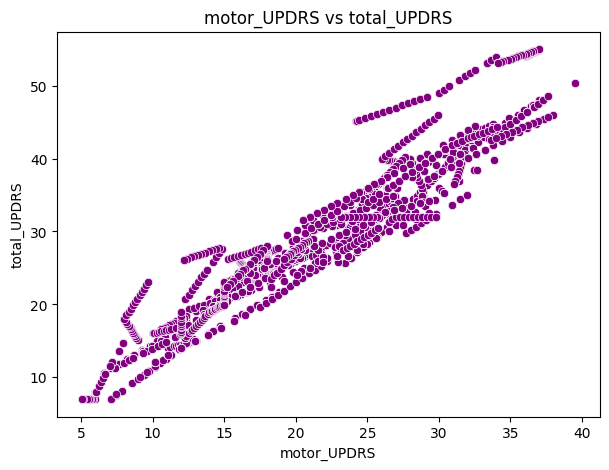

In [37]:
# 1. Scatter plot of target vs most correlated feature
most_corr = correlations.index[1]
plt.figure(figsize=(7,5))
sns.scatterplot(x=df2[most_corr], y=df2[target], color='purple')
plt.title(f"{most_corr} vs {target}")
plt.xlabel(most_corr)
plt.ylabel(target)
plt.show()

The plot shows how the 'total_UPDRS' score changes as the 'motor_UPDRS' score changes.

The points  follow a roughly upward trend, which shows a positive correlation between these two variables. This indicates that as the motor symptoms ('motor_UPDRS') worsen, the overall Parkinson's disease severity ('total_UPDRS') also tends to increase.

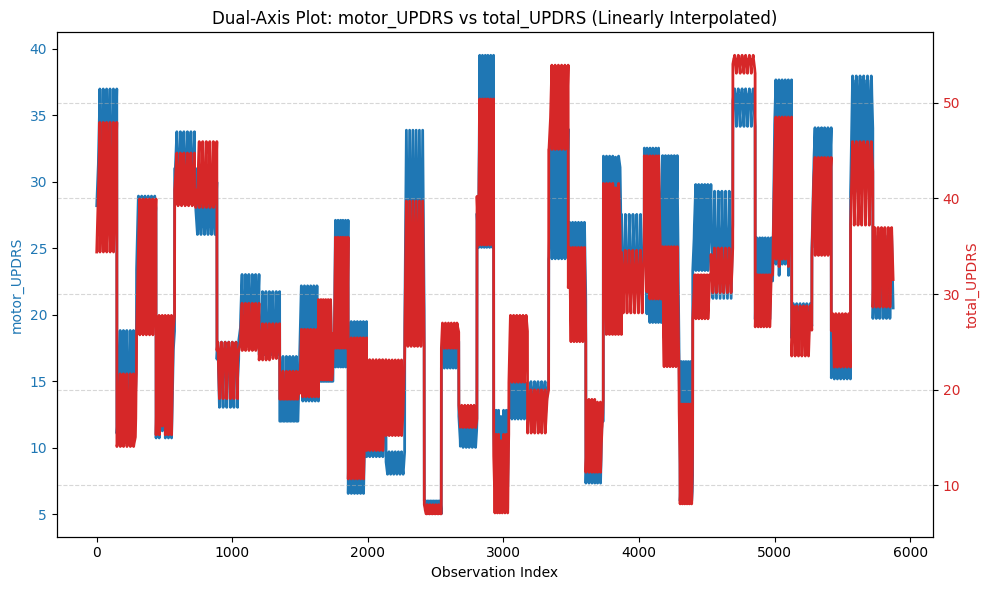

In [33]:
if 'motor_UPDRS' in df2.columns and 'total_UPDRS' in df2.columns:
    fig, ax1 = plt.subplots(figsize=(10,6))

    color1 = 'tab:blue'
    ax1.set_xlabel('Observation Index')
    ax1.set_ylabel('motor_UPDRS', color=color1)
    ax1.plot(df['motor_UPDRS'], color=color1, linewidth=2, label='motor_UPDRS')
    ax1.tick_params(axis='y', labelcolor=color1)

    ax2 = ax1.twinx()  # create second y-axis
    color2 = 'tab:red'
    ax2.set_ylabel('total_UPDRS', color=color2)
    ax2.plot(df2['total_UPDRS'], color=color2, linewidth=2, label='total_UPDRS')
    ax2.tick_params(axis='y', labelcolor=color2)

    plt.title("Dual-Axis Plot: motor_UPDRS vs total_UPDRS (Linearly Interpolated)")
    fig.tight_layout()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()
else:
    print("⚠️ Columns 'motor_UPDRS' and/or 'total_UPDRS' not found in dataset.")

Left Y-Axis represents motor_UPDRS.This measures motor function only (movement, speech, tremor, etc.).
Right Y-Axis is total_UPDRS, which is the overall disease severity score, combining motor and non-motor symptoms.
X-Axis shows the observation index (each voice sample or measurement).
Each point corresponds to one observation in the dataset.

Trend Direction:
When both lines rise together, it indicates that as the motor symptoms worsen, the overall disease severity also increases a strong positive relationship.

Gap Between Lines:
The vertical distance between the two lines shows how much the motor symptoms contribute to the total score.
A consistent gap means a stable contribution; a widening gap could mean non-motor symptoms are becoming more influential.



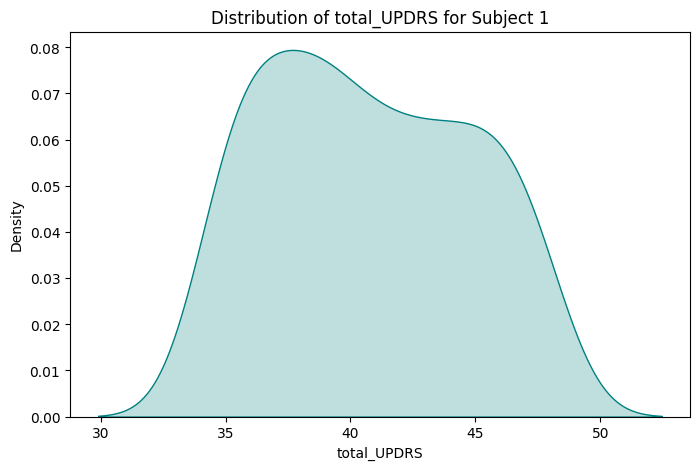

In [31]:
# plot showing trends for one patient

first_subject_df = df2[df2[subj_col] == df2[subj_col].unique()[0]]

# a distribution plot for the target variable for subject 1
plt.figure(figsize=(8, 5))
sns.kdeplot(first_subject_df[target], fill=True, color='teal')
plt.title(f"Distribution of {target} for Subject {df2[subj_col].unique()[0]}")
plt.xlabel(target)
plt.ylabel("Density")
plt.show()


The KDE plot shows how a single patient’s total_UPDRS scores vary over time.
Subject 1’s UPDRS distribution indicates consistent scores with gradual progression  aligning with the six-month longitudinal design of the dataset.

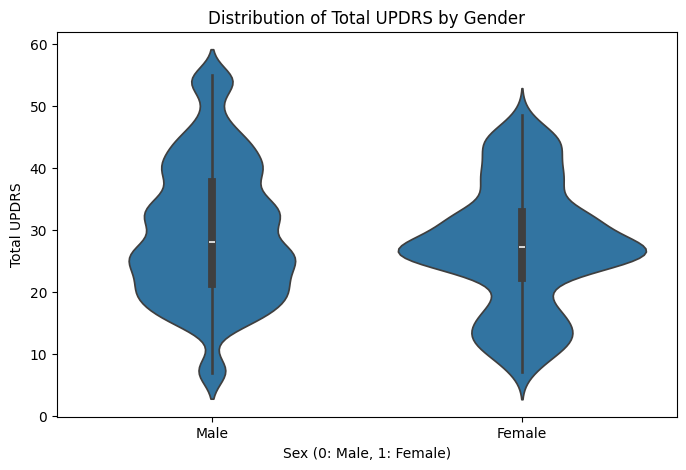

In [23]:
plt.figure(figsize=(8, 5))
sns.violinplot(x='sex', y='total_UPDRS', data=df)
plt.title("Distribution of Total UPDRS by Gender")
plt.xlabel("Sex (0: Male, 1: Female)")
plt.ylabel("Total UPDRS")
plt.xticks([0, 1], ['Male', 'Female'])
plt.show()

The violin plot compares total_UPDRS distributions between male and female participants.

While both genders show similar median scores, females exhibit slightly broader variability.
This links to the research reported that individual physiological differences (such as vocal pitch range and breath control) may cause small gender-related variability in acoustic markers, though the study found no significant gender bias in UPDRS progression

In [27]:
jitter_features = ['Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP']
updrs_scores = ['motor_UPDRS', 'total_UPDRS']

# Calculate correlations
jitter_correlations = df[jitter_features + updrs_scores].corr()

# Display correlations with UPDRS scores
print("Correlation of Jitter Features with UPDRS Scores:")
display(jitter_correlations.loc[jitter_features, updrs_scores])

Correlation of Jitter Features with UPDRS Scores:


,motor_UPDRS,total_UPDRS
Jitter(%),0.084816,0.074247
Jitter(Abs),0.050903,0.066927
Jitter:RAP,0.072684,0.064015
Jitter:PPQ5,0.076291,0.063352
Jitter:DDP,0.072698,0.064027


In [28]:
shimmer_features = ['Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA']
updrs_scores = ['motor_UPDRS', 'total_UPDRS']

# Calculate correlations
shimmer_correlations = df[shimmer_features + updrs_scores].corr()

# Display correlations with UPDRS scores
print("Correlation of Shimmer Features with UPDRS Scores:")
display(shimmer_correlations.loc[shimmer_features, updrs_scores])

Correlation of Shimmer Features with UPDRS Scores:


,motor_UPDRS,total_UPDRS
Shimmer,0.102349,0.092141
Shimmer(dB),0.110076,0.098790
Shimmer:APQ3,0.084261,0.079363
Shimmer:APQ5,0.092105,0.083467
Shimmer:APQ11,0.136560,0.120838
Shimmer:DDA,0.084260,0.079363


**Analysis of Jitter and Shimmer Feature Correlations with UPDRS Scores**


**Jitter Features:**

*   The Jitter features show relatively low positive correlations with both motor UPDRS` and `total_UPDRS`.
*   The correlation values range from approximately 0.05 to 0.08 for motor UPDRS` and 0.06 to 0.07 for `total_UPDRS`.
*   This indicates that while there is a slight tendency for Jitter measures to increase as UPDRS scores increase, the relationship is weak.

**Shimmer Features:**

*   The Shimmer features show relatively low positive correlations with both `motor_UPDRS` and `total_UPDRS`.
*   The correlation values for Shimmer features are slightly higher than those for Jitter features, ranging from approximately 0.08 to 0.14 for `motor_UPDRS` and 0.08 to 0.12 for `total_UPDRS`.
*   `Shimmer:APQ11` shows the highest correlation among the Shimmer features with both `motor_UPDRS` (0.136) and `total_UPDRS` (0.121).
*   This suggests a slightly stronger, but still weak, positive relationship between Shimmer measures and UPDRS scores compared to Jitter measures.





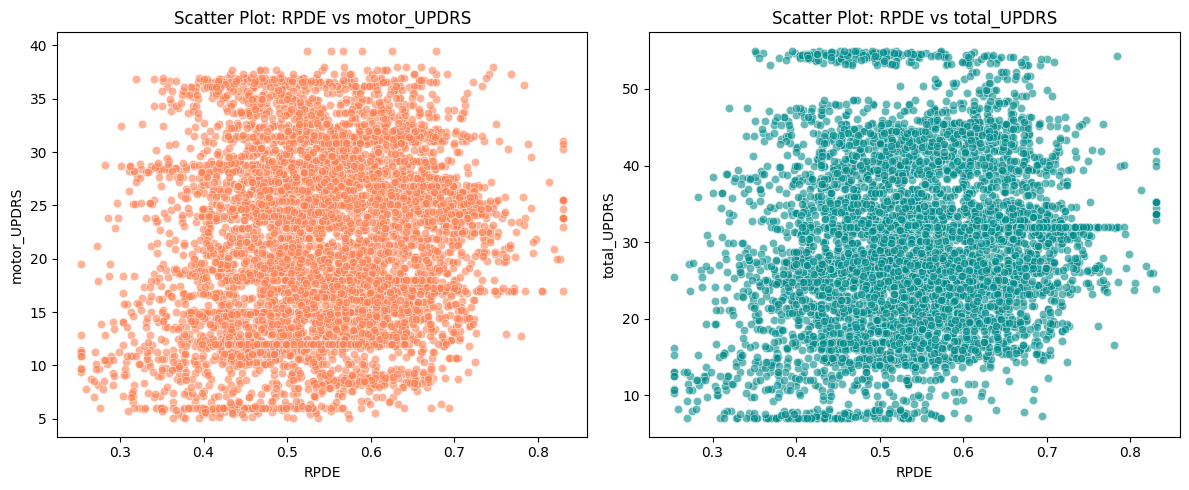

In [38]:
# Scatter plots for RPDE vs UPDRS scores
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=df2['RPDE'], y=df2['motor_UPDRS'], color='coral', alpha=0.6)
plt.title('Scatter Plot: RPDE vs motor_UPDRS')
plt.xlabel('RPDE')
plt.ylabel('motor_UPDRS')

plt.subplot(1, 2, 2)
sns.scatterplot(x=df2['RPDE'], y=df2['total_UPDRS'], color='darkcyan', alpha=0.6)
plt.title('Scatter Plot: RPDE vs total_UPDRS')
plt.xlabel('RPDE')
plt.ylabel('total_UPDRS')

plt.tight_layout()
plt.show()

**Analysis of RPDE vs. UPDRS Scatter Plots**

The points are scattered across the plot, and while there might be a general trend, it doesn't appear to be a strong linear one.
Some of the  clustering of data points or patterns are not simply increasing or decreasing in a straight line. This supports the idea of a non-linear relationship. The relationship between voice signal complexity (as measured by RPDE) and Parkinson's severity (UPDRS scores) is more complex than a simple linear association.

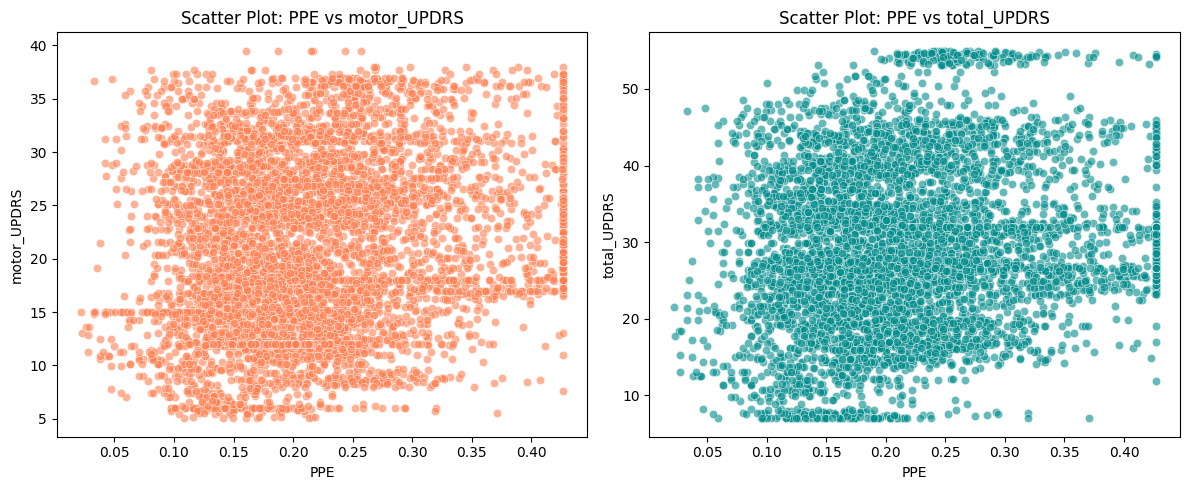

In [30]:
# Scatter plots for PPE vs UPDRS scores
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=df2['PPE'], y=df2['motor_UPDRS'], color='coral', alpha=0.6)
plt.title('Scatter Plot: PPE vs motor_UPDRS')
plt.xlabel('PPE')
plt.ylabel('motor_UPDRS')

plt.subplot(1, 2, 2)
sns.scatterplot(x=df2['PPE'], y=df2['total_UPDRS'], color='darkcyan', alpha=0.6)
plt.title('Scatter Plot: PPE vs total_UPDRS')
plt.xlabel('PPE')
plt.ylabel('total_UPDRS')

plt.tight_layout()
plt.show()

**Analysis of PPE vs. UPDRS Scatter Plots**

The scatter plots for PPE against UPDRS scores show a dispersed pattern, suggesting a non-linear relationship.
These plots reinforce that PPE's relationship with Parkinson's severity is not strictly linear and likely contributes in a more complex way to the overall UPDRS score.

### Limitations



The following were the shortfalls within the dataset

**Outliers**: The presence of outliers in several features like Jitter and Shimmer measures, NHR, HNR, RPDE, and PPE can influence the results.

**Data Collection Method**: The data was collected via telemonitoring using a device to record speech signals in patients' homes. While convenient, this method might introduce variability or inconsistencies compared to clinical settings.

**Limited Feature Types**: The dataset primarily consists of biomedical voice measurements. While these are relevant to Parkinson's, other factors that influence UPDRS scores (e.g., medication, other health conditions, lifestyle) are not included, which could limit the scope of analysis and prediction.

**Interpolated UPDRS Scores:** The motor and total UPDRS scores are linearly interpolated, which means there are  recorded scores and might not be the exact scores from every single time point but rather estimated values between actual clinical assessments.